# DeepLOB: Deep Convolutional Neural Networks for Limit Order Books, implemented with Early Bird ticket technique

### DeepLOB: Deep Convolutional Neural Networks for Limit Order Books: Zihao Zhang, Stefan Zohren and Stephen Roberts
Oxford-Man Institute of Quantitative Finance, Department of Engineering Science, University of Oxford

### Drawing Early-Bird Tickets: Towards More Efficient Training of Deep Networks: You, Li et al
Department of Electrical and Computer Engineering, Rice University; Department of Computer Science and Engineering, Texas A&M University

This jupyter notebook is used to demonstrate the paper [2] published in IEEE Transactions on Singal Processing. Used FI-2010 [1] dataset and present how model architecture is constructed here. 

### Data:
The FI-2010 is publicly avilable and interested readers can check out their paper [1]. The dataset can be downloaded from: https://etsin.fairdata.fi/dataset/73eb48d7-4dbc-4a10-a52a-da745b47a649 

Otherwise, the notebook will download the data automatically or it can be obtained from: 

https://drive.google.com/drive/folders/1Xen3aRid9ZZhFqJRgEMyETNazk02cNmv?usp=sharing

### References:
[1] Ntakaris A, Magris M, Kanniainen J, Gabbouj M, Iosifidis A. Benchmark dataset for mid‐price forecasting of limit order book data with machine learning methods. Journal of Forecasting. 2018 Dec;37(8):852-66. https://arxiv.org/abs/1705.03233

[2] Zhang Z, Zohren S, Roberts S. DeepLOB: Deep convolutional neural networks for limit order books. IEEE Transactions on Signal Processing. 2019 Mar 25;67(11):3001-12. https://arxiv.org/abs/1808.03668

In [1]:
import os 
if not os.path.isfile('data.zip'):
    !wget https://raw.githubusercontent.com/zcakhaa/DeepLOB-Deep-Convolutional-Neural-Networks-for-Limit-Order-Books/master/data/data.zip
    !unzip -n data.zip
    print('data downloaded.')
else:
    print('data already existed.')

--2026-02-28 10:14:50--  https://raw.githubusercontent.com/zcakhaa/DeepLOB-Deep-Convolutional-Neural-Networks-for-Limit-Order-Books/master/data/data.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.110.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 56278154 (54M) [application/zip]
Saving to: ‘data.zip’

data.zip            100%[===================>]  53.67M   286MB/s    in 0.2s    

2026-02-28 10:14:52 (286 MB/s) - ‘data.zip’ saved [56278154/56278154]

Archive:  data.zip
  inflating: Test_Dst_NoAuction_DecPre_CF_7.txt  
  inflating: Test_Dst_NoAuction_DecPre_CF_9.txt  
  inflating: Test_Dst_NoAuction_DecPre_CF_8.txt  
  inflating: Train_Dst_NoAuction_DecPre_CF_7.txt  
data downloaded.


In [2]:
!pip install torchinfo

In [3]:
# load packages
import pandas as pd
import pickle
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
from tqdm import tqdm 
from sklearn.metrics import accuracy_score, classification_report

import torch
import torch.nn.functional as F
from torch.utils import data
from torchinfo import summary
import torch.nn as nn
import torch.optim as optim
# from sklearn.model_selection import train_test_split
# X_train, X_test, y_train, y_test = train_test_split(data.data, data.target, test_size=0.33)
# N, D = X_train.shape

In [4]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)

cuda:0


In [5]:
def prepare_x(data):
    df1 = data[:40, :].T
    return np.array(df1)

def get_label(data):
    lob = data[-5:, :].T
    return lob

def data_classification(X, Y, T):
    [N, D] = X.shape
    df = np.array(X)

    dY = np.array(Y)

    dataY = dY[T - 1:N]

    dataX = np.zeros((N - T + 1, T, D))
    for i in range(T, N + 1):
        dataX[i - T] = df[i - T:i, :]

    return dataX, dataY

def torch_data(x, y):
    x = torch.from_numpy(x)
    x = torch.unsqueeze(x, 1)
    y = torch.from_numpy(y)
    y = F.one_hot(y, num_classes=3)
    return x, y

In [6]:
class Dataset(data.Dataset):
    """Characterizes a dataset for PyTorch"""
    def __init__(self, data, k, num_classes, T):
        """Initialization""" 
        self.k = k
        self.num_classes = num_classes
        self.T = T
            
        x = prepare_x(data)
        y = get_label(data)
        x, y = data_classification(x, y, self.T)
        y = y[:,self.k] - 1
        self.length = len(x)

        x = torch.from_numpy(x)
        self.x = torch.unsqueeze(x, 1)
        self.y = torch.from_numpy(y)

    def __len__(self):
        """Denotes the total number of samples"""
        return self.length

    def __getitem__(self, index):
        """Generates samples of data"""
        return self.x[index], self.y[index]

# Data preparation

Used no auction dataset that is normalised by decimal precision approach in their work. The first seven days are training data and the last three days are testing data. A validation set (20%) from the training set is used to monitor the overfitting behaviours.  

The first 40 columns of the FI-2010 dataset are 10 levels ask and bid information for a limit order book and we only use these 40 features in our network. The last 5 columns of the FI-2010 dataset are the labels with different prediction horizons. 

In [7]:
# please change the data_path to your local path
# data_path = '/nfs/home/zihaoz/limit_order_book/data'

dec_data = np.loadtxt('Train_Dst_NoAuction_DecPre_CF_7.txt')
dec_train = dec_data[:, :int(np.floor(dec_data.shape[1] * 0.8))]
dec_val = dec_data[:, int(np.floor(dec_data.shape[1] * 0.8)):]

dec_test1 = np.loadtxt('Test_Dst_NoAuction_DecPre_CF_7.txt')
dec_test2 = np.loadtxt('Test_Dst_NoAuction_DecPre_CF_8.txt')
dec_test3 = np.loadtxt('Test_Dst_NoAuction_DecPre_CF_9.txt')
dec_test = np.hstack((dec_test1, dec_test2, dec_test3))

print(dec_train.shape, dec_val.shape, dec_test.shape)

(149, 203800) (149, 50950) (149, 139587)


In [8]:
batch_size = 64

dataset_train = Dataset(data=dec_train, k=4, num_classes=3, T=100)
dataset_val = Dataset(data=dec_val, k=4, num_classes=3, T=100)
dataset_test = Dataset(data=dec_test, k=4, num_classes=3, T=100)

train_loader = torch.utils.data.DataLoader(dataset=dataset_train, batch_size=batch_size, shuffle=True)
val_loader = torch.utils.data.DataLoader(dataset=dataset_val, batch_size=batch_size, shuffle=False)
test_loader = torch.utils.data.DataLoader(dataset=dataset_test, batch_size=batch_size, shuffle=False)

print(dataset_train.x.shape, dataset_train.y.shape)

torch.Size([203701, 1, 100, 40]) torch.Size([203701])


In [9]:
tmp_loader = torch.utils.data.DataLoader(dataset=dataset_train, batch_size=1, shuffle=True)

for x, y in tmp_loader:
    print(x)
    print(y)
    print(x.shape, y.shape)
    break

tensor([[[[0.1245, 0.0239, 0.1241,  ..., 0.0420, 0.1231, 0.0370],
          [0.1245, 0.0239, 0.1241,  ..., 0.0420, 0.1231, 0.0370],
          [0.1245, 0.0239, 0.1241,  ..., 0.0420, 0.1231, 0.0370],
          ...,
          [0.1241, 0.0364, 0.1240,  ..., 0.0332, 0.1231, 0.0370],
          [0.1241, 0.0550, 0.1240,  ..., 0.0332, 0.1231, 0.0370],
          [0.1241, 0.0550, 0.1240,  ..., 0.0332, 0.1231, 0.0370]]]],
       dtype=torch.float64)
tensor([2.], dtype=torch.float64)
torch.Size([1, 1, 100, 40]) torch.Size([1])


## Model architecture

The model


In [10]:
class deeplob(nn.Module):
    def __init__(self, y_len):
        super().__init__()
        self.y_len = y_len
        
        # convolution blocks
        self.conv1 = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=32, kernel_size=(1,2), stride=(1,2)),
            nn.LeakyReLU(negative_slope=0.01),
#             nn.Tanh(),
            nn.BatchNorm2d(32),
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=(4,1)),
            nn.LeakyReLU(negative_slope=0.01),
            nn.BatchNorm2d(32),
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=(4,1)),
            nn.LeakyReLU(negative_slope=0.01),
            nn.BatchNorm2d(32),
        )
        self.conv2 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=(1,2), stride=(1,2)),
            nn.Tanh(),
            nn.BatchNorm2d(32),
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=(4,1)),
            nn.Tanh(),
            nn.BatchNorm2d(32),
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=(4,1)),
            nn.Tanh(),
            nn.BatchNorm2d(32),
        )
        self.conv3 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=(1,10)),
            nn.LeakyReLU(negative_slope=0.01),
            nn.BatchNorm2d(32),
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=(4,1)),
            nn.LeakyReLU(negative_slope=0.01),
            nn.BatchNorm2d(32),
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=(4,1)),
            nn.LeakyReLU(negative_slope=0.01),
            nn.BatchNorm2d(32),
        )
        
        # inception moduels
        self.inp1 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=(1,1), padding='same'),
            nn.LeakyReLU(negative_slope=0.01),
            nn.BatchNorm2d(64),
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=(3,1), padding='same'),
            nn.LeakyReLU(negative_slope=0.01),
            nn.BatchNorm2d(64),
        )
        self.inp2 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=(1,1), padding='same'),
            nn.LeakyReLU(negative_slope=0.01),
            nn.BatchNorm2d(64),
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=(5,1), padding='same'),
            nn.LeakyReLU(negative_slope=0.01),
            nn.BatchNorm2d(64),
        )
        self.inp3 = nn.Sequential(
            nn.MaxPool2d((3, 1), stride=(1, 1), padding=(1, 0)),
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=(1,1), padding='same'),
            nn.LeakyReLU(negative_slope=0.01),
            nn.BatchNorm2d(64),
        )
        
        # lstm layers
        self.lstm = nn.LSTM(input_size=192, hidden_size=64, num_layers=1, batch_first=True)
        self.fc1 = nn.Linear(64, self.y_len)

    def forward(self, x):
        # h0: (number of hidden layers, batch size, hidden size)
        h0 = torch.zeros(1, x.size(0), 64).to(device)
        c0 = torch.zeros(1, x.size(0), 64).to(device)
    
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        
        x_inp1 = self.inp1(x)
        x_inp2 = self.inp2(x)
        x_inp3 = self.inp3(x)  
        
        x = torch.cat((x_inp1, x_inp2, x_inp3), dim=1)
        
#         x = torch.transpose(x, 1, 2)
        x = x.permute(0, 2, 1, 3)
        x = torch.reshape(x, (-1, x.shape[1], x.shape[2]))
        
        x, _ = self.lstm(x, (h0, c0))
        x = x[:, -1, :]
        x = self.fc1(x)
        forecast_y = torch.softmax(x, dim=1)
        
        return forecast_y

In [11]:
model = deeplob(y_len = dataset_train.num_classes)
model.to(device)

# Save initial weights for reset
init_weights = {name: param.clone().detach() for name, param in model.named_parameters()}

def get_pruning_masks(model, prune_ratio=0.2):
    masks = {}
    conv_layers = [
        'conv1.0.weight', 'conv1.3.weight', 'conv1.6.weight',
        'conv2.0.weight', 'conv2.3.weight', 'conv2.6.weight',
        'conv3.0.weight', 'conv3.3.weight', 'conv3.6.weight',
        'inp1.0.weight',  'inp1.3.weight',
        'inp2.0.weight',  'inp2.3.weight',
        'inp3.1.weight',
    ]
    
    for name in conv_layers:
        param = dict(model.named_parameters())[name]
        weight = param.data  # [out, in, kh, kw]
        norms = weight.abs().sum(dim=(1,2,3))   # L1 norm per output channel
        num_keep = max(1, int(norms.numel() * (1 - prune_ratio)))
        _, indices = torch.topk(norms, num_keep)
        mask = torch.zeros_like(norms, dtype=torch.bool, device=norms.device)
        mask[indices] = True
        masks[name] = mask
    
    return masks

def compute_mask_distance(m1, m2):
    dist = 0.0
    count = 0
    for key in m1:
        if key in m2:
            inter = (m1[key] & m2[key]).sum().item()
            union = (m1[key] | m2[key]).sum().item()
            d = 1 - (inter / union) if union > 0 else 0.0
            dist += d
            count += 1
    return dist / count if count > 0 else 0.0

def prune_sequential(
    seq, 
    weight_names,          # list of weight parameter names in order
    output_masks_dict,     # dict: name → output channel mask (boolean tensor)
    input_mask,            # boolean tensor for this block's input channels
    device
):
    """
    Prune a nn.Sequential block of Conv2d + BN + Act layers.
    Returns: new output channels count, updated input mask for NEXT block
    """
    current_in = input_mask.sum().item() if input_mask is not None else 1
    prev_out_mask = input_mask  # for the first conv in block

    w_idx = 0
    for i, module in enumerate(seq):
        if isinstance(module, nn.Conv2d):
            name = weight_names[w_idx]
            out_mask = output_masks_dict[name]          # boolean [old_out_channels]

            # 1. Slice input channels using previous block's output mask
            if prev_out_mask is not None:
                module.weight.data = module.weight.data[:, prev_out_mask, :, :]

            # 2. Slice output channels using this layer's mask
            module.weight.data = module.weight.data[out_mask, :, :, :]

            if module.bias is not None:
                module.bias.data = module.bias.data[out_mask]

            # Create new conv layer with correct shapes
            new_out = out_mask.sum().item()
            new_conv = nn.Conv2d(
                in_channels=current_in,
                out_channels=new_out,
                kernel_size=module.kernel_size,
                stride=module.stride,
                padding=module.padding,
                dilation=module.dilation,
                groups=module.groups,
                bias=module.bias is not None
            ).to(device)

            # Copy surviving weights
            new_conv.weight.data.copy_(module.weight.data)
            if module.bias is not None:
                new_conv.bias.data.copy_(module.bias.data)

            seq[i] = new_conv

            # Update for next conv in SAME block (if any)
            prev_out_mask = out_mask
            current_in = new_out
            w_idx += 1

        elif isinstance(module, nn.BatchNorm2d):
            # Prune BN using the latest output mask (from last conv)
            if prev_out_mask is not None:
                module.weight.data = module.weight.data[prev_out_mask]
                module.bias.data = module.bias.data[prev_out_mask]
                module.running_mean = module.running_mean[prev_out_mask]
                module.running_var = module.running_var[prev_out_mask]

                new_bn = nn.BatchNorm2d(
                    num_features=prev_out_mask.sum().item(),
                    eps=module.eps, momentum=module.momentum,
                    affine=module.affine, track_running_stats=module.track_running_stats
                ).to(device)

                new_bn.weight.data.copy_(module.weight.data)
                new_bn.bias.data.copy_(module.bias.data)
                new_bn.running_mean.copy_(module.running_mean)
                new_bn.running_var.copy_(module.running_var)
                new_bn.num_batches_tracked.copy_(module.num_batches_tracked)

                seq[i] = new_bn

    # Return final output channels and the mask to pass to next block
    final_out_mask = prev_out_mask   # last conv's output mask
    return final_out_mask.sum().item(), final_out_mask

def prune_model(model, masks, device):
    # masks is dict: weight_name → boolean mask of kept OUTPUT channels

    # Start with input = 1 channel
    input_mask = torch.ones(1, dtype=torch.bool, device=device)

    # ---------------- Conv1 ----------------
    conv1_names = ['conv1.0.weight', 'conv1.3.weight', 'conv1.6.weight']
    conv1_out_channels, conv1_out_mask = prune_sequential(
        model.conv1, conv1_names, masks, input_mask, device
    )
    model.conv1_out = conv1_out_channels

    # ---------------- Conv2 ----------------
    conv2_names = ['conv2.0.weight', 'conv2.3.weight', 'conv2.6.weight']
    conv2_out_channels, conv2_out_mask = prune_sequential(
        model.conv2, conv2_names, masks, conv1_out_mask, device
    )
    model.conv2_out = conv2_out_channels

    # ---------------- Conv3 ----------------
    conv3_names = ['conv3.0.weight', 'conv3.3.weight', 'conv3.6.weight']
    conv3_out_channels, conv3_out_mask = prune_sequential(
        model.conv3, conv3_names, masks, conv2_out_mask, device
    )
    model.conv3_out = conv3_out_channels

    # ---------------- Inception branches ----------------
    # inp1
    inp1_names = ['inp1.0.weight', 'inp1.3.weight']
    inp1_out_ch, inp1_out_mask = prune_sequential(
        model.inp1, inp1_names, masks, conv3_out_mask, device
    )

    # inp2
    inp2_names = ['inp2.0.weight', 'inp2.3.weight']
    inp2_out_ch, inp2_out_mask = prune_sequential(
        model.inp2, inp2_names, masks, conv3_out_mask, device
    )

    # inp3 (has MaxPool + Conv)
    inp3_names = ['inp3.1.weight']  # only one conv
    inp3_out_ch, inp3_out_mask = prune_sequential(
        model.inp3, inp3_names, masks, conv3_out_mask, device
    )

    # ---------------- Fix LSTM input size ----------------
    kept_indices = []
    offset = 0
    for branch_out_mask, branch_size in [
        (inp1_out_mask, inp1_out_ch),
        (inp2_out_mask, inp2_out_ch),
        (inp3_out_mask, inp3_out_ch)
    ]:
        kept = torch.nonzero(branch_out_mask).squeeze(-1) + offset
        kept_indices.append(kept)
        offset += branch_size

    kept_feat_idx = torch.cat(kept_indices)

    old_lstm = model.lstm
    new_input_size = kept_feat_idx.numel()

    model.lstm = nn.LSTM(
        input_size=new_input_size,
        hidden_size=64,
        num_layers=1,
        batch_first=True
    ).to(device)

    # Copy weights (only input-hidden weights change)
    with torch.no_grad():
        model.lstm.weight_ih_l0.copy_(old_lstm.weight_ih_l0[:, kept_feat_idx])
        model.lstm.weight_hh_l0.copy_(old_lstm.weight_hh_l0)
        model.lstm.bias_ih_l0.copy_(old_lstm.bias_ih_l0)
        model.lstm.bias_hh_l0.copy_(old_lstm.bias_hh_l0)

    print(f"Pruned model → LSTM input size reduced to {new_input_size}")

    return model

# Parameters for EB
prune_ratio = 0.2  # 20% pruning
threshold = 0.5
window = 5
warmup_epochs = 10

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

# Training to find EB ticket
mask_history = []
eb_found = False
eb_masks = None
for it in tqdm(range(50)):  # Train up to 50 epochs or until EB found
    model.train()
    train_loss = []
    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device, dtype=torch.float), targets.to(device, dtype=torch.int64)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        train_loss.append(loss.item())
    train_loss = np.mean(train_loss)

    model.eval()
    val_loss = []
    for inputs, targets in val_loader:
        inputs, targets = inputs.to(device, dtype=torch.float), targets.to(device, dtype=torch.int64)
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        val_loss.append(loss.item())
    val_loss = np.mean(val_loss)

    print(f'Epoch {it+1}, Train Loss: {train_loss:.4f}, Validation Loss: {val_loss:.4f}')

    if it >= warmup_epochs:
        current_masks = get_pruning_masks(model, prune_ratio)
        mask_history.append(current_masks)
        if len(mask_history) > window:
            recent_dists = [compute_mask_distance(mask_history[i], mask_history[i+1]) for i in range(-window-1, -1)]
            if all(d < threshold for d in recent_dists):
                eb_found = True
                eb_masks = mask_history[-1]
                print(f"Early-Bird Ticket found at epoch {it+1}")
                break

if not eb_found:
    print("No Early-Bird Ticket found, using full model")
    # Proceed with full model
else:
    # Create pruned model from initial weights
    pruned_model = deeplob(y_len = dataset_train.num_classes).to(device)
    for name, param in pruned_model.named_parameters():
        param.data = init_weights[name].clone()
    pruned_model = prune_model(pruned_model, eb_masks, device)
    
    # Now train the pruned model from scratch
    optimizer = torch.optim.Adam(pruned_model.parameters(), lr=0.0001)
    train_losses, val_losses = batch_gd(pruned_model, criterion, optimizer, train_loader, val_loader, epochs=50)

    # Save the best
    torch.save(pruned_model, 'best_val_model_pytorch_eb')

# The rest of the notebook for testing uses the pruned_model or the original if not found
model = torch.load('best_val_model_pytorch_eb')

  2%|▏         | 1/50 [00:55<45:14, 55.40s/it]

Epoch 1, Train Loss: 0.9393, Validation Loss: 1.0450


  4%|▍         | 2/50 [01:48<43:07, 53.90s/it]

Epoch 2, Train Loss: 0.8384, Validation Loss: 0.9649


  6%|▌         | 3/50 [02:41<41:54, 53.51s/it]

...

 30%|███       | 15/50 [13:21<31:07, 53.37s/it]

Epoch 15, Train Loss: 0.7007, Validation Loss: 0.8859


 30%|███       | 15/50 [14:13<33:11, 56.91s/it]

Epoch 16, Train Loss: 0.6973, Validation Loss: 0.8826
Early-Bird Ticket found at epoch 16
Pruned model → LSTM input size reduced to 153


NameError: name 'batch_gd' is not defined

In [13]:
torch.save(pruned_model, 'best_val_model_pytorch_eb')

In [14]:
summary(model, (1, 1, 100, 40))

Layer (type:depth-idx)                   Output Shape              Param #
deeplob                                  [1, 3]                    --
├─Sequential: 1-1                        [1, 32, 94, 20]           --
│    └─Conv2d: 2-1                       [1, 32, 100, 20]          96
│    └─LeakyReLU: 2-2                    [1, 32, 100, 20]          --
│    └─BatchNorm2d: 2-3                  [1, 32, 100, 20]          64
│    └─Conv2d: 2-4                       [1, 32, 97, 20]           4,128
│    └─LeakyReLU: 2-5                    [1, 32, 97, 20]           --
│    └─BatchNorm2d: 2-6                  [1, 32, 97, 20]           64
│    └─Conv2d: 2-7                       [1, 32, 94, 20]           4,128
│    └─LeakyReLU: 2-8                    [1, 32, 94, 20]           --
│    └─BatchNorm2d: 2-9                  [1, 32, 94, 20]           64
├─Sequential: 1-2                        [1, 32, 88, 10]           --
│    └─Conv2d: 2-10                      [1, 32, 94, 10]           2,080
│    └

In [16]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

## Model training

In [19]:
class deeplob(nn.Module):
    def __init__(self, y_len):
        super().__init__()
        self.y_len = y_len
        
        # convolution blocks
        self.conv1 = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=32, kernel_size=(1,2), stride=(1,2)),
            nn.LeakyReLU(negative_slope=0.01),
#             nn.Tanh(),
            nn.BatchNorm2d(32),
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=(4,1)),
            nn.LeakyReLU(negative_slope=0.01),
            nn.BatchNorm2d(32),
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=(4,1)),
            nn.LeakyReLU(negative_slope=0.01),
            nn.BatchNorm2d(32),
        )
        self.conv2 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=(1,2), stride=(1,2)),
            nn.Tanh(),
            nn.BatchNorm2d(32),
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=(4,1)),
            nn.Tanh(),
            nn.BatchNorm2d(32),
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=(4,1)),
            nn.Tanh(),
            nn.BatchNorm2d(32),
        )
        self.conv3 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=(1,10)),
            nn.LeakyReLU(negative_slope=0.01),
            nn.BatchNorm2d(32),
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=(4,1)),
            nn.LeakyReLU(negative_slope=0.01),
            nn.BatchNorm2d(32),
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=(4,1)),
            nn.LeakyReLU(negative_slope=0.01),
            nn.BatchNorm2d(32),
        )
        
        # inception moduels
        self.inp1 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=(1,1), padding='same'),
            nn.LeakyReLU(negative_slope=0.01),
            nn.BatchNorm2d(64),
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=(3,1), padding='same'),
            nn.LeakyReLU(negative_slope=0.01),
            nn.BatchNorm2d(64),
        )
        self.inp2 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=(1,1), padding='same'),
            nn.LeakyReLU(negative_slope=0.01),
            nn.BatchNorm2d(64),
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=(5,1), padding='same'),
            nn.LeakyReLU(negative_slope=0.01),
            nn.BatchNorm2d(64),
        )
        self.inp3 = nn.Sequential(
            nn.MaxPool2d((3, 1), stride=(1, 1), padding=(1, 0)),
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=(1,1), padding='same'),
            nn.LeakyReLU(negative_slope=0.01),
            nn.BatchNorm2d(64),
        )
        
        # lstm layers
        self.lstm = nn.LSTM(input_size=192, hidden_size=64, num_layers=1, batch_first=True)
        self.fc1 = nn.Linear(64, self.y_len)

    def forward(self, x):
        # h0: (number of hidden layers, batch size, hidden size)
        h0 = torch.zeros(1, x.size(0), 64).to(device)
        c0 = torch.zeros(1, x.size(0), 64).to(device)
    
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        
        x_inp1 = self.inp1(x)
        x_inp2 = self.inp2(x)
        x_inp3 = self.inp3(x)  
        
        x = torch.cat((x_inp1, x_inp2, x_inp3), dim=1)
        
#         x = torch.transpose(x, 1, 2)
        x = x.permute(0, 2, 1, 3)
        x = torch.reshape(x, (-1, x.shape[1], x.shape[2]))
        
        x, _ = self.lstm(x, (h0, c0))
        x = x[:, -1, :]
        x = self.fc1(x)
        forecast_y = torch.softmax(x, dim=1)
        
        return forecast_y

Pruned model loaded successfully (safe mode).
LSTM input size: 153


In [23]:
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm
from datetime import datetime
import numpy as np

# ──── Paths & device ────────────────────────────────────────────────
MODEL_PATH = "/kaggle/working/best_val_model_pytorch_eb"
SAVE_PATH  = "/kaggle/working/best_pruned_model_finetuned.pt"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ──── Load pruned model ─────────────────────────────────────────────
pruned_model = torch.load(
    MODEL_PATH,
    map_location=device,
    weights_only=False   # ← this allows custom classes
)
pruned_model.to(device)
pruned_model.train()  # or .eval() if you only want inference

print("Pruned model loaded.")
print("Current LSTM input size:", pruned_model.lstm.input_size)

# ──── Loss, optimizer, scheduler ────────────────────────────────────
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(pruned_model.parameters(), lr=5e-5)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=5,
    threshold=1e-4,
    min_lr=1e-7
)

epochs = 40
best_val_loss = float('inf')

train_losses = []
val_losses = []

print(f"Starting fine-tuning for {epochs} epochs...")

for epoch in range(epochs):
    pruned_model.train()
    t0 = datetime.now()
    train_loss = 0.0
    train_count = 0

    for inputs, targets in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
        inputs = inputs.to(device, dtype=torch.float)
        targets = targets.to(device, dtype=torch.long)

        optimizer.zero_grad()
        outputs = pruned_model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * inputs.size(0)
        train_count += inputs.size(0)

    train_loss /= train_count
    train_losses.append(train_loss)

    # Validation
    pruned_model.eval()
    val_loss = 0.0
    val_count = 0

    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs = inputs.to(device, dtype=torch.float)
            targets = targets.to(device, dtype=torch.long)
            outputs = pruned_model(inputs)
            loss = criterion(outputs, targets)
            val_loss += loss.item() * inputs.size(0)
            val_count += inputs.size(0)

    val_loss /= val_count
    val_losses.append(val_loss)

    # Scheduler step + log lr change
    prev_lr = optimizer.param_groups[0]['lr']
    scheduler.step(val_loss)
    curr_lr = optimizer.param_groups[0]['lr']

    # Save best
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(pruned_model, SAVE_PATH)
        print(f"  → New best saved | val loss: {val_loss:.5f}")

    dt = datetime.now() - t0
    print(f"Epoch {epoch+1:3d}/{epochs} | "
          f"train: {train_loss:.5f} | val: {val_loss:.5f} | "
          f"lr: {curr_lr:.2e} | "
          f"time: {dt.seconds//60:2d}m {dt.seconds%60:02d}s")

    if curr_lr < prev_lr:
        print(f"      ↓ Learning rate reduced to {curr_lr:.2e}")

print("\nTraining finished.")
print(f"Best validation loss: {best_val_loss:.5f}")
print(f"Best model saved to: {SAVE_PATH}")

Pruned model loaded.
Current LSTM input size: 153
Starting fine-tuning for 40 epochs...


Epoch 1: 100%|██████████| 3183/3183 [00:39<00:00, 79.70it/s]


  → New best saved | val loss: 1.02466
Epoch   1/40 | train: 0.98630 | val: 1.02466 | lr: 5.00e-05 | time:  0m 43s


Epoch 2: 100%|██████████| 3183/3183 [00:40<00:00, 79.01it/s]


  → New best saved | val loss: 1.01472
Epoch   2/40 | train: 0.88996 | val: 1.01472 | lr: 5.00e-05 | time:  0m 43s


...

Epoch  38/40 | train: 0.69702 | val: 0.94726 | lr: 6.25e-06 | time:  0m 43s
      ↓ Learning rate reduced to 6.25e-06


Epoch 39: 100%|██████████| 3183/3183 [00:40<00:00, 78.32it/s]


Epoch  39/40 | train: 0.69454 | val: 0.94787 | lr: 6.25e-06 | time:  0m 43s


Epoch 40: 100%|██████████| 3183/3183 [00:38<00:00, 81.88it/s]


Epoch  40/40 | train: 0.69361 | val: 0.94714 | lr: 6.25e-06 | time:  0m 41s

Training finished.
Best validation loss: 0.93881
Best model saved to: /kaggle/working/best_pruned_model_finetuned.pt


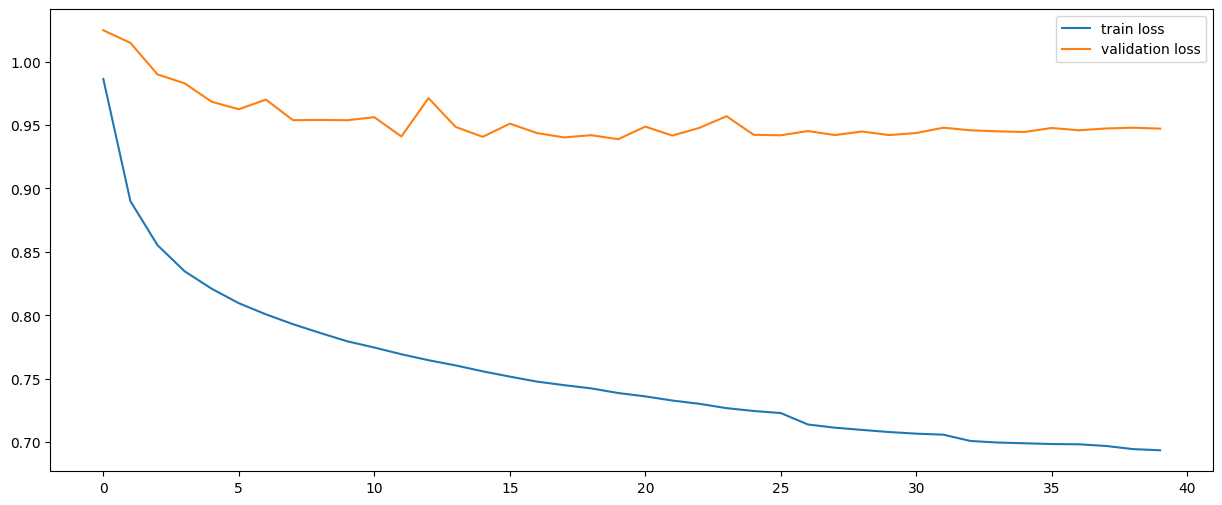

In [24]:
plt.figure(figsize=(15,6))
plt.plot(train_losses, label='train loss')
plt.plot(val_losses, label='validation loss')
plt.legend()

## Model Testing

In [25]:
# Load the pruned model
pruned_model = torch.load(
    MODEL_PATH,
    map_location=device,
    weights_only=False   
)
pruned_model.to(device)
pruned_model.eval()  

# Your original testing code
n_correct = 0.
n_total = 0.
all_targets = []
all_predictions = []

for inputs, targets in test_loader:
    inputs, targets = inputs.to(device, dtype=torch.float), targets.to(device, dtype=torch.int64)
    outputs = model(inputs)
    _, predictions = torch.max(outputs, 1)
    
    n_correct += (predictions == targets).sum().item()
    n_total += targets.shape[0]
    
    all_targets.append(targets.cpu().numpy())
    all_predictions.append(predictions.cpu().numpy())

test_acc = n_correct / n_total
print(f"Test acc (pruned model): {test_acc:.4f}")

from sklearn.metrics import accuracy_score, classification_report
all_targets = np.concatenate(all_targets)
all_predictions = np.concatenate(all_predictions)
print('accuracy_score:', accuracy_score(all_targets, all_predictions))
print(classification_report(all_targets, all_predictions, digits=4))

Test acc (pruned model): 0.7473
accuracy_score: 0.7473402729983941
              precision    recall  f1-score   support

           0     0.7440    0.7297    0.7368     47915
           1     0.7895    0.7718    0.7805     48050
           2     0.7073    0.7398    0.7232     43523

    accuracy                         0.7473    139488
   macro avg     0.7469    0.7471    0.7468    139488
weighted avg     0.7482    0.7473    0.7476    139488



### Conclusion
- Pruned model has shrunk in size by 20% (from 192 to 153)
- Reduce training time by 60% (early bird exit from epoch 16/50, winners appear around 10%-30% epoch time) and thus inference time due to sparser network, yet maintained a test accuracy of 74%, which is just 1% away from training the whole model without pruning

-   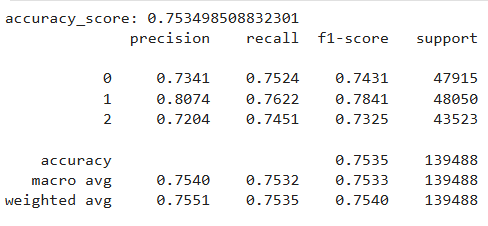 
    
    Evaluation on full model indicates that pruning, like what we have done with decision trees, indeed are effective at reducing train and test time. A sparser model is similar to L1/L2 regularization, which adds protection against overfitting. The difference is, L1/L2 regularization does not reduce training cost, Early Bird does.

- Sparser models also allow greater interpretability, since we can investigate further why some speific paths in the network have a higher performance than others. Another novel technique is to reverse engineer the neural network, similar to what have been done by Jane Street (https://blog.janestreet.com/can-you-reverse-engineer-our-neural-network/)